In [56]:
from BoardDetection import BoardDetection
from Dataset.DataSetLoaders.ChessDataset import ChessDataset

import os
import sys

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.nn import functional as F

from sklearn.model_selection import train_test_split

from torchvision import transforms
from torchvision import models
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image

import math
import pickle
from tqdm.auto import tqdm

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [6]:
BE = BoardDetection.BoardExtractor()
def preprocess_fn(padding=(0,0)):
    def main(img):
        BE.set_img(img)
        quad, conf = BE.extract_board()
        warpped, M = BE.warp(quad, padding=padding)
        
        return warpped

    return main

def post_transform(img):
    return torch.tensor(img).permute(2,0,1)

In [57]:
ds = ChessDataset(
    config={
        "img_size": (640,640),
    },
    img_transforms = transforms.Compose([
            preprocess_fn((32,32)),
            post_transform,
        ])
)

train_ds, test_ds = train_test_split(ds, test_size=0.1, random_state=42)

train_dl = ChessDataset.getLoader(train_ds, 16, 0)
test_dl = ChessDataset.getLoader(test_ds, 16, 0)

KeyboardInterrupt: 

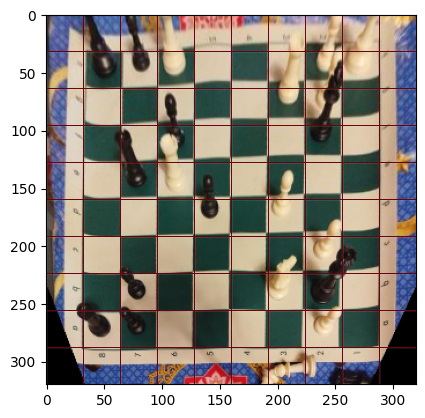

In [8]:
warpped, y = ds[0]

grid = np.zeros((warpped.shape[1], warpped.shape[2]))
step = 32
# Set pixels in rows and columns that are multiples of step to 1
grid[::step, :] = 1   # horizontal lines
grid[:, ::step] = 1   # vertical lines

plt.imshow(warpped.permute(1,2,0));
plt.imshow(grid, alpha=grid, cmap='Reds');

In [29]:
class PieceDetectorCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.resnet = models.resnet18(pretrained=True)
        for param in self.resnet.parameters():
            param.requires_grad = False
        self.resnet = nn.Sequential(*list(self.resnet.children())[:-1])  # Remove the last FC layer and avgpool
        for param in self.resnet[-1].parameters():
            param.requires_grad = True

        dropporb = .2

        # self.conv1 = nn.Sequential(
        #     # 32, 32
        #     nn.Conv2d(3, 16, 3, padding=1),
        #     nn.LeakyReLU(),
        #     nn.BatchNorm2d(16),
        #     nn.MaxPool2d(4),
        #     nn.Dropout(dropporb),

        #     # 8, 8
        #     nn.Conv2d(16, 64, 3, padding=1),
        #     nn.LeakyReLU(),
        #     nn.BatchNorm2d(64),
        #     nn.MaxPool2d(4),
        #     nn.Dropout(dropporb),

        #     # 2,2
        #     nn.Conv2d(64, 128, 3, padding=1),
        #     nn.LeakyReLU(),
        #     nn.BatchNorm2d(128),
        #     nn.MaxPool2d(2),
        #     nn.Dropout(dropporb),

        #     # 1, 1
        # )

        self.conv1 = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 128),
            nn.LeakyReLU(),
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(128, 128, 3, padding=1),
            nn.LeakyReLU(),
            # nn.BatchNorm2d(128),
            nn.Dropout(dropporb),

            nn.Conv2d(128, 128, 3, padding=1),
            nn.LeakyReLU(),
            # nn.BatchNorm2d(128),
            nn.Dropout(dropporb),
        )

        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.LeakyReLU(),
            nn.Dropout(dropporb),
        )

        self.classifier_heads = {
            "occupancy": nn.Linear(64, 1),
            "piece_color": nn.Linear(64, 1),
            "piece_type": nn.Linear(64, 6),
        }

        self.pos_emb = nn.Parameter(torch.zeros(128, 10, 10))
        self.sin_pos_emb = None  # [C, 10, 10]

    def sinusoidal_embeddings_2d(self, height=10, width=10, d_model=128):
        """
        Create 2D sinusoidal positional embeddings for an (H, W) grid.

        height, width: grid size
        d_model: total embedding dimension (should be even)

        Returns:
            pos_emb: [H, W, d_model] tensor
        """
        if self.sin_pos_emb is not None and (tuple(self.sin_pos_emb.shape) == (d_model, height, width)):
            return self.sin_pos_emb

        if d_model % 4 != 0:
            raise ValueError("d_model must be divisible by 4 for 2D sin/cos.")

        # Position indices
        y_pos = torch.arange(height, dtype=torch.float32).unsqueeze(1)  # [H, 1]
        x_pos = torch.arange(width, dtype=torch.float32).unsqueeze(1)   # [W, 1]

        # Each axis gets d_model/2 dimensions, split into sin/cos → d_model/4 each
        d_model_half = d_model // 2
        div_term = torch.exp(torch.arange(0, d_model_half, 2).float() * (-math.log(10000.0) / d_model_half))

        # Row (y) embeddings
        pe_y = torch.zeros(height, d_model_half)
        pe_y[:, 0::2] = torch.sin(y_pos * div_term)
        pe_y[:, 1::2] = torch.cos(y_pos * div_term)

        # Col (x) embeddings
        pe_x = torch.zeros(width, d_model_half)
        pe_x[:, 0::2] = torch.sin(x_pos * div_term)
        pe_x[:, 1::2] = torch.cos(x_pos * div_term)

        # Combine row and col into [H, W, d_model]
        pe = torch.zeros(height, width, d_model)
        for i in range(height):
            for j in range(width):
                pe[i, j] = torch.cat([pe_y[i], pe_x[j]], dim=0)

        self.sin_pos_emb = pe.permute(2, 0, 1).to(device)
        return self.sin_pos_emb

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        sq_size = (x.shape[2]//10, x.shape[3]//10)
        B = x.shape[0]
        C = x.shape[1]
        if C != 3:
            raise Exception("Invalid Image")
        
        board_split = x.reshape(B, C, 10, sq_size[0], 10, sq_size[1]).permute(0,1,2,4,3,5)

        # embeds = self.conv1(board_split.permute(0,2,3,1,4,5).reshape(-1,C,sq_size[0],sq_size[1])).squeeze(-1).squeeze(-1).reshape(B, 10,10, 128).permute(0,3,1,2)
        embeds = self.conv1(self.resnet(board_split.permute(0,2,3,1,4,5).reshape(-1,C,sq_size[0],sq_size[1]))).squeeze(-1).squeeze(-1).reshape(B, 10,10, 128).permute(0,3,1,2)

        sin_pos_emb = self.sinusoidal_embeddings_2d(10,10, 128)

        positioned_embeds = embeds + self.pos_emb + sin_pos_emb
        # attentioned_embeds = embeds.reshape(B, 10,10, 128).permute(0,3,1,2)
        attentioned_embeds = self.conv2(positioned_embeds)
        cropped_attentioned_embeds = attentioned_embeds[:,:,1:9,1:9]
        res = self.classifier(cropped_attentioned_embeds.permute(0,2,3,1).reshape(-1, 128))
        res_occupancy = self.classifier_heads["occupancy"](res).reshape(B, 8,8)
        res_piece_color = self.classifier_heads["piece_color"](res).reshape(B, 8,8)
        res_piece_type = self.classifier_heads["piece_type"](res).reshape(B, 8,8, 6)

        return {
            "occupancy": res_occupancy,
            "piece_color": res_piece_color,
            "piece_type": res_piece_type,
        }

In [30]:
model = PieceDetectorCNN().to(device)

torch.Size([16, 8, 8])
torch.Size([16, 8, 8])
torch.Size([16, 8, 8, 6])


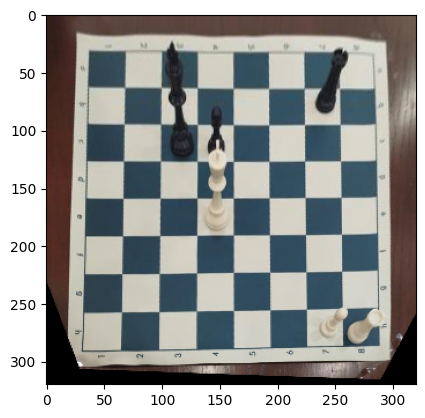

In [31]:
for x, l in dl:
    res = model(x.to(device))
    print(res["occupancy"].shape)
    print(res["piece_color"].shape)
    print(res["piece_type"].shape)
    # print(res.shape)
    # print(l)

    plt.imshow(x[0].permute(1,2,0));
    break

In [54]:
def train(model: nn.Module, train_loader, lr=1e-3, epochs=30):
    optimzier = torch.optim.Adam(model.parameters(), lr=lr)
    # class_weights = 64/(torch.tensor([8,2,2,2,1,1,8,2,2,2,1,1,32]))
    # loss_fn = nn.CrossEntropyLoss(weight=class_weights.to(device))
    loss_fn_binary = nn.BCEWithLogitsLoss()
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        train_loss = 0
        train_acc = {
            "occupancy": 0,
            "piece_color": 0,
            "piece_type": 0,
        }
        train_count = 0
        train_occupied_count = 0
        for X, L in tqdm(train_loader):
            y = L["board_tensor"]
            X = X.to(device)
            y = y.to(device)

            preds: torch.Tensor = model(X)
            preds["occupancy"] = preds["occupancy"].reshape(-1)
            preds["piece_color"] = preds["piece_color"].reshape(-1)
            preds["piece_type"] = preds["piece_type"].reshape(-1, 6)

            # y = y.reshape(-1, 13)
            y_occupancy = (y < 12).to(torch.float32).reshape(-1)
            y_piece_color = (y<6).to(torch.float32).reshape(-1)
            y_piece_type = (y%6).to(torch.float32).reshape(-1)
            # y_piece_type = F.one_hot(y_piece_type.to(torch.long), 6)

            optimzier.zero_grad()
            loss: torch.Tensor = loss_fn_binary(preds["occupancy"], y_occupancy) + \
                loss_fn_binary(preds["piece_color"]*y_occupancy, (y_piece_color)*y_occupancy) + \
                loss_fn(preds["piece_type"]*y_occupancy.unsqueeze(1), (y_piece_type*y_occupancy).to(torch.long))
            loss.backward()
            optimzier.step()

            train_loss += loss.item()
            train_count += X.shape[0]*8*8
            train_occupied_count += y_occupancy.sum().item()

            train_acc["occupancy"] += ((preds["occupancy"].sigmoid() > .5) == y_occupancy).sum().item()
            train_acc["piece_color"] += ((preds["piece_color"].sigmoid() > .5)*y_occupancy == y_piece_color*y_occupancy).sum().item()
            train_acc["piece_type"] += ((preds["piece_type"].softmax(dim=1).argmax(dim=1))*y_occupancy == y_piece_type*y_occupancy).sum().item()

        train_loss /= train_count
        train_acc["occupancy"] /= train_count
        train_acc["piece_color"] /= train_occupied_count
        train_acc["piece_type"] /= train_occupied_count

        print(f"Epoch {epoch+1}/{epochs} |  Loss {train_loss:.4f} | Accuracy {train_acc:.2f}")

In [ ]:
train(model, train_dl, epochs=10)

  0%|          | 0/23 [00:00<?, ?it/s]c:\Users\Taw\Desktop\ChessLensRepo\thesis_chess_lens\.venv\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
 13%|█▎        | 3/23 [00:16<01:48,  5.41s/it]


KeyboardInterrupt: 

In [28]:
torch.save(model.state_dict(), "best_model.pt")

In [ ]:
from Utils import ChessUtils

In [32]:
f = ds[0][1]["fen"]
ChessUtils.ChessTensorUtils().FENtoTensor(f).permute(0,2,3,1)[0,0,0]

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.])

In [33]:
cu = ChessUtils.ChessTensorUtils()

In [ ]:
cu = ChessUtils.ChessTensorUtils()
with open("../data/data_manual/full_dataset/annotations_manual.pkl", "rb") as f:
    x = pickle.load(f)

for i in range(len(x)):
    x[i]["y"] = cu.FENtoTensor(x[i]["fen"]).permute(0,2,3,1).squeeze().rot90(-1, (0,1))

with open("../data/data_manual/full_dataset/annotations_manual_2.pkl", "wb") as f:
    pickle.dump(x, f)

(tensor([[ 3, 12, 12,  0, 12, 12,  6,  9],
         [12,  0, 12, 12, 12, 12,  6, 12],
         [ 2, 12,  1, 12,  6, 12, 12,  8],
         [ 4,  0, 12, 12,  6, 12,  7, 10],
         [12,  0, 12, 12, 12,  6, 12, 11],
         [ 3,  0, 12, 12, 12, 12,  6,  8],
         [ 5,  2,  0, 12, 12, 12,  6, 12],
         [12,  0, 12, 12, 12, 12,  6,  9]]),
 '../data/data_manual/full_dataset/manual_dataset/images/img1.jpg',
 tensor(2))

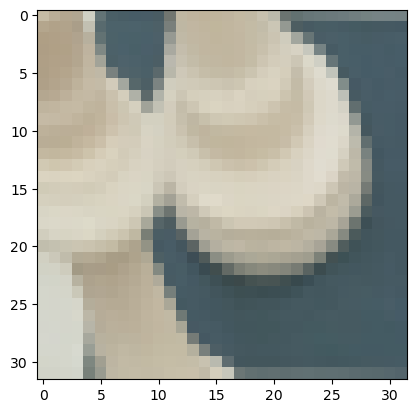

In [20]:
x, y = ds[0]

x = x.unsqueeze(0)

sq_size = (x.shape[2]//10, x.shape[3]//10)
B = x.shape[0]
C = x.shape[1]
if C != 3:
    raise Exception("Invalid Image")

board_split = x.reshape(B, C, 10, sq_size[0], 10, sq_size[1]).permute(0,1,2,4,3,5)

plt.imshow(board_split[0,:,3,1,:,:].permute(1,2,0));

y['y'].argmax(dim=2), y['file_path'], y['y'].argmax(dim=2)[2,0]

In [34]:
with torch.inference_mode():
    x = ds[0][0].unsqueeze(0).to(device)
    preds = model(x)
preds.shape

torch.Size([1, 8, 8, 13])

In [35]:
board = preds.squeeze().argmax(2).rot90(1).unsqueeze(0)
print(board.shape)
cu.tensorToFEN_MAX(board)

torch.Size([1, 8, 8])


'r1bqkb1r/pp1n1ppp/4p3/2pp4/P7/2B3P1/1P1NP1BP/R1BQ1RK1'

In [36]:
img = Image.open("../data/data_old/9.jpeg").convert("RGB").resize((640,640))
img = ds.transforms(img)

with torch.inference_mode():
    x = img.unsqueeze(0).to(device)
    preds = model(x)

board = preds.squeeze().argmax(2).rot90(1).unsqueeze(0)
cu.tensorToFEN_MAX(board)

'3r1r1r/pp2kQpp/2ppn3/1pP1n1P1/7P/3QP3/P4R2/RQ2R2R'